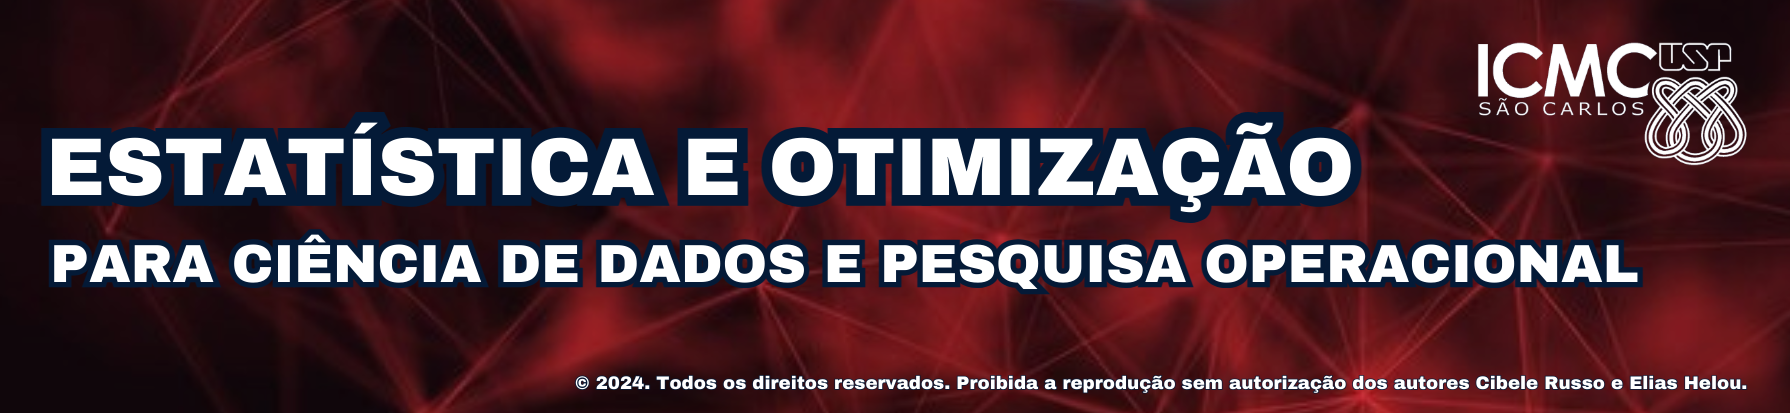

<h1 style = 'text-align: center;'>Otimização Matemática</h1>

por **Elias Helou**

**ICMC/USP - São Carlos SP**

<h2>Conteúdo da aula</h2>

1. Função objetivo

2. Restrições

3. Otimizador global

4. Otimizador local

<h2>Função objetivo</h2>

Em um problema de otimização, procuramos pela melhor solução possível, que chamamos de _otimizador_. O que quantifica a qualidade das soluções é a função objetivo
$$
    f: \mathbb R^n \to \mathbb R.
$$
Todo problema de otimização tem uma função objetivo.

Além da função objetivo, todo problema de otimização tem uma direção de otimização: podemos querer maximizar ou minimizar a função objetivo.

<h3>Exemplos</h3>

- Se as soluções $\def\vect{\boldsymbol}\vect x$ são os possíveis caminhos entre duas cidades, $f( \vect x )$ pode ser
    - o tempo de viagem;
    - o custo total da viagem.

- Se as soluções $\vect x$ são as possíveis quantidades produzidas de cada um dos produtos de uma companhia, $f( \vect x )$ provavelmente representará o lucro a ser obtido.

- Suponha que $\vect x = ( a, r )$ onde $a$ e $r$ são a altura e o raio de uma lata cilíndrica. Então a área da lata utilizada em sua construção é
$$
    f( a, r ) = 2\pi r^2 + 2\pi ra = 2\pi r( r + a ).
$$

<!--
    Para as widgets funcionarem no renderizador de notebooks JuPyTer do VSCode foi necessário
    conectar a um servidor JuPyTer para o qual as widgets estejam funcionando. Usar um kernel
    qualquer não deu certo, mesmo configurando ambas as fontes de widgets sugeridas pelo VSCode.

    Para instalar e configurar as widgets no servidor eu fiz

    pip3 install --upgrade ipywidgets
    jupyter nbextension enable --py widgetsnbextension
-->

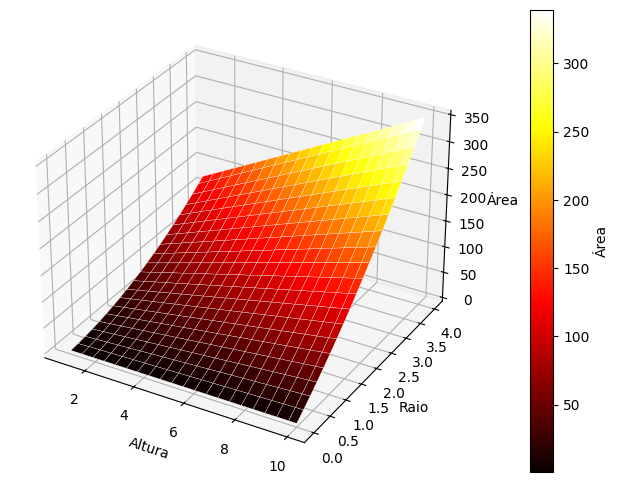

In [1]:
import numpy as np
import matplotlib.pyplot as pp

vol = 50.0

a_mx = 10.0

def a2r( a ):
    return ( vol / ( np.pi * a ) ) ** 0.5

N = 60
a = np.linspace( 1.0, a_mx, N )
r = np.linspace( 0.0, np.max( a2r( a ) ), N )
A, R = np.meshgrid( a, r )

def fun( A, R ):
    return 2 * np.pi * R * ( A + R )

Z = fun( A, R )

fig = pp.figure( figsize = ( 15, 6 ) )

rs = cs = 3
alpha = 1.0
cmap = pp.cm.hot

ax = fig.add_subplot( 1, 1, 1, projection = '3d' )
surf = ax.plot_surface( A, R, Z, alpha = alpha, cmap = cmap, rstride = rs, cstride = cs, linewidth = 0.2, edgecolor = 'white' )
ax.set_xlabel( 'Altura' )
ax.set_ylabel( 'Raio' )
ax.set_zlabel( 'Área' )
pp.colorbar( surf, label = 'Área' )

pp.show()


- Veja que o menor valor possível para a área de material utilizado na fabricação da lata é $0$;

- Seria possível obter até valores negativos, da forma como o problema está definido;

- Mas isso não faz sentido na prática, pois é necessário embalar o produto para venda.

<h2>Restrições</h2>

Em muitos problemas, alguns conjuntos de valores para as variáveis de decisão são inválidos. Por exemplo

- Caminhos que não começam na origem ou que não chegam ao destino;

- Quantidades que excedam a capacidade de produção de empresas;

- Dimensões da lata que não resultem no volume $v$ planejado de produto:
$$
    \pi r^2 a = v.
$$


As restrições excluem soluções que não pertence ao _conjunto viável_  
$$
    \mathbb X \subset \mathbb R^n.
$$

Um problema de otimização em geral tem a forma
$$\def\sa{\text{s.\ a:}}
    \begin{align*}
        \min &\quad f(\vect x)\\
        \sa  &\quad \vect x \in \mathbb X.
    \end{align*}
$$

Por exemplo, se precisamos vender latas com um volume $v$, o conjunto $\mathbb X$ tem a forma
$$
    \{ ( a, r ): \pi r^2 a = v \}.
$$
Ou, equivalentemente,
$$
    ( a, r ) = \left( a, \sqrt{ \frac v{\pi a} } \right).
$$

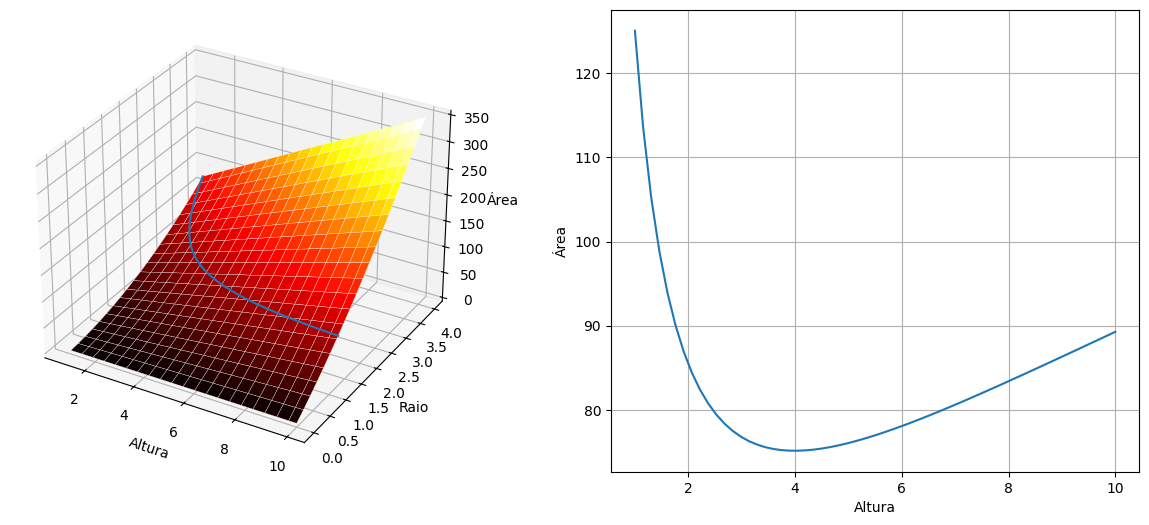

In [2]:
fig = pp.figure( figsize = ( 15, 6 ) )

ax = fig.add_subplot( 1, 2, 1, projection = '3d' )
ax.plot3D( a, a2r( a ), fun( a, a2r( a ) ), zorder = 10 )
surf = ax.plot_surface( A, R, Z, alpha = alpha, cmap = cmap, rstride = rs, cstride = cs, linewidth = 0.2, edgecolor = 'white' )
ax.set_xlabel( 'Altura' )
ax.set_ylabel( 'Raio' )
ax.set_zlabel( 'Área' )

ax = fig.add_subplot( 1, 2, 2 )
ax.plot( a, fun( a, a2r( a ) ) )
ax.set_xlabel( 'Altura' )
ax.set_ylabel( 'Área' )
ax.grid()

pp.show()

<h2>Otimizador Global</h2>

Dizemos que $\vect x^*$ é um minimizador global de
$$\def\sa{\text{s.\ a}}
    \begin{align*}
        \min &\quad f(\vect x)\\
        \sa  &\quad \vect x \in \mathbb X.
    \end{align*}
$$
se $\vect x^* \in \mathbb X$ e
$$
    f( \vect x^* ) \le f( \vect x )\quad \forall \vect x \in \mathbb X.
$$
Um maximizador global é definido de forma semelhante.

É importante observar que pode não existir um minimizador global.

<h3>Exercícios</h3>

Encontre exemplos de problemas de otimização com

- Nenhum minimizador global

- Um único minimizador global

- Mais de um minimizador global

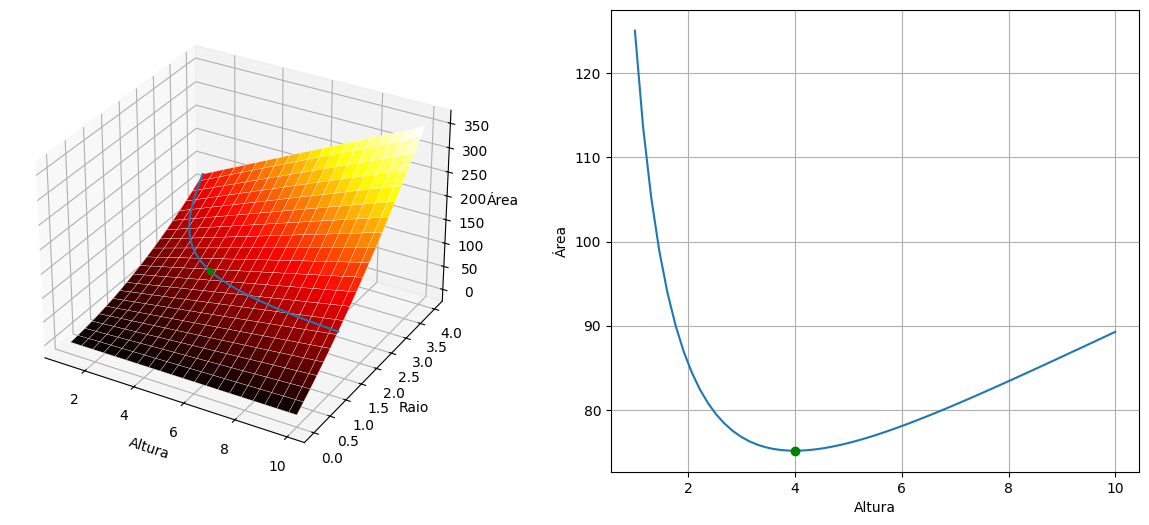

Altura:	 3.9929454255865284
Raio:	 1.9964727120946781
Área:	 75.13250698284078
Volume:	 50.0


In [3]:
import scipy.optimize as opt

def f( a ):

    return fun( a, a2r( a ) )

res = opt.minimize_scalar( f, bracket = ( 1.0e-1, 10 ) )
x = res.x

fig = pp.figure( figsize = ( 15, 6 ) )

ax = fig.add_subplot( 1, 2, 1, projection = '3d', computed_zorder = False )
ax.plot3D( a, a2r( a ), fun( a, a2r( a ) ), zorder = 10 )
surf = ax.plot_surface( A, R, Z, alpha = alpha, cmap = cmap, rstride = rs, cstride = cs, linewidth = 0.2, edgecolor = 'white' )
ax.scatter3D( x, a2r( x ), fun( x, a2r( x ) ), c = 'green', zorder = 10 )
ax.set_xlabel( 'Altura' )
ax.set_ylabel( 'Raio' )
ax.set_zlabel( 'Área' )

ax = fig.add_subplot( 1, 2, 2 )
ax.plot( a, fun( a, a2r( a ) ) )
ax.scatter( x, fun( x, a2r( x ) ), c = 'green', zorder = 10 )
ax.set_xlabel( 'Altura' )
ax.set_ylabel( 'Área' )
ax.grid()

pp.show()

print( 'Altura:\t', x )
print( 'Raio:\t', a2r( x ) )
print( 'Área:\t', f( x ) )
print( 'Volume:\t', np.pi * a2r( x ) ** 2 * x )

<h2>Otimizador Local</h2>

Um conceito de extrema importância em otimização é o de minimizador local.

Dizemos que $\vect x^*$ é um minimizador local de
$$\def\sa{\text{s.\ a}}
    \begin{align*}
        \min &\quad f(\vect x)\\
        \sa  &\quad \vect x \in \mathbb X.
    \end{align*}
$$
se $\vect x^* \in \mathbb X$ e existe $\epsilon > 0$ tal que
$$
    f( \vect x^* ) \le f( \vect x )\quad \forall \vect x \in \mathbb X\text{ tal que }\| \vect x - \vect x^* \| \ge \epsilon.
$$
Um maximizador local é definido de forma semelhante.

- Minimizadores locais são mais fáceis de encontrar e de reconhecer;
- Somente abordaremos técnicas para minimização local;
- Em alguns casos (otimização linear e otimização convexa) minimizadores locais são minimizadores globais.

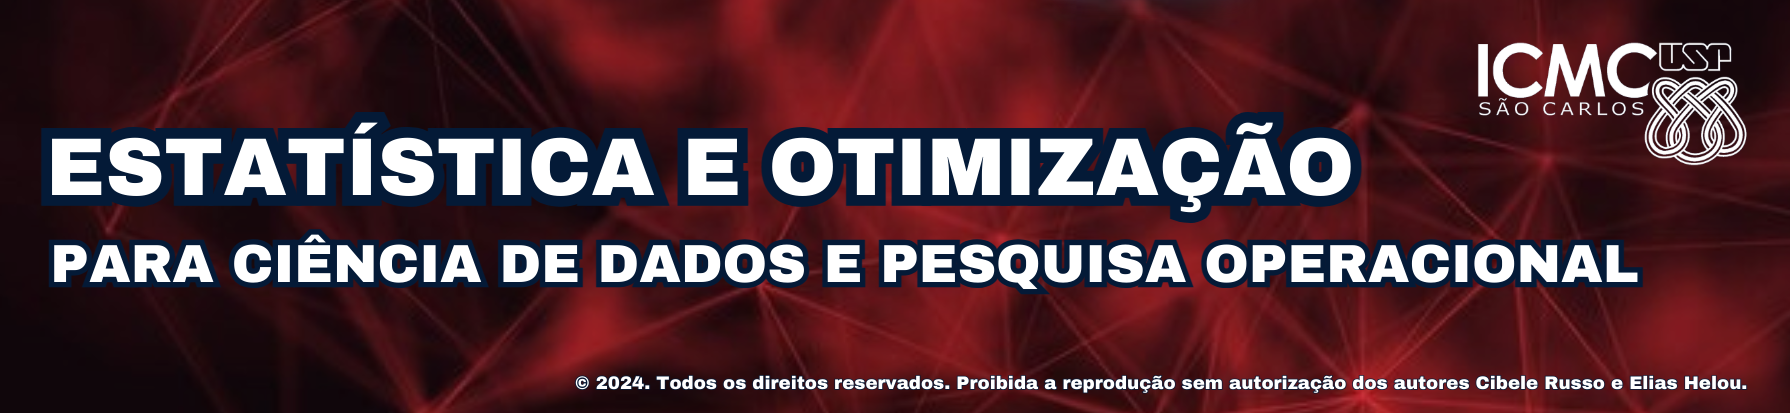

<h1 style = 'text-align: center;'>Otimização Matemática</h1>

por **Elias Helou**

**ICMC/USP - São Carlos SP**

<h2>Conteúdo do Vídeo</h2>

4. Otimizador local

5. Operações que preservam a solução

6. Otimização univariada sem restrições

<h2>4. Otimizador Local</h2>

Um conceito de extrema importância em otimização é o de minimizador local.

Dizemos que $\def\vect{\boldsymbol}\vect x^*$ é um minimizador local de
$$\def\sa{\text{s.\ a:}}
    \begin{align*}
        \min &\quad f(\vect x)\\
        \sa  &\quad \vect x \in \mathbb X.
    \end{align*}
$$
se $\vect x^* \in \mathbb X$ e existe $\epsilon > 0$ tal que
$$
    f( \vect x^* ) \le f( \vect x )
$$
$$
     \forall \vect x \in \mathbb X\quad\text{tal que}\quad\| \vect x - \vect x^* \| \le \epsilon.
$$

Um maximizador local é definido de forma semelhante.

- Minimizadores locais são mais fáceis de encontrar e de reconhecer;
- Em alguns casos (otimização linear e otimização convexa) minimizadores locais são minimizadores globais.

<h3>4.1 Exemplo</h3>

Considere a função
$$
    f( x ) = x + 3\cos( x ).
$$

Esta função possui múltiplos minimizadores locais, mas nenhum minimizador global!

<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_19533/3889896634.py:15: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/3889896634.py:15: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/3889896634.py:15: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/3889896634.py:15: SyntaxWarning: invalid escape sequence '\p'
  

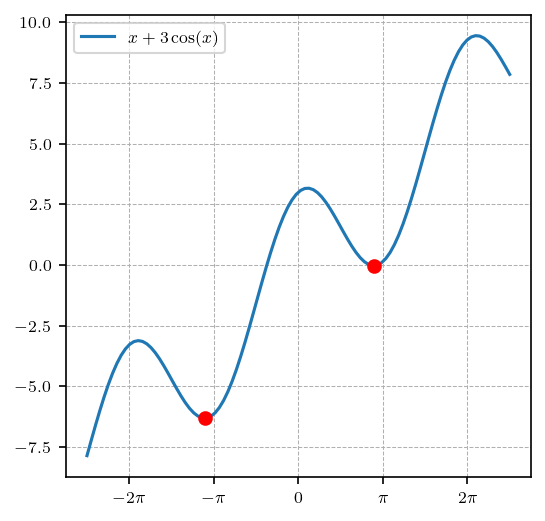

In [10]:
import matplotlib.pyplot as pp
pp.rcParams[ 'text.usetex' ] = True
pp.rcParams[ 'font.size' ] = 8
pp.rcParams[ 'figure.dpi' ] = 150
import numpy as np

def f( x ):
    return x + 3 * np.cos( x )

x = np.linspace( -2.5 * np.pi, 2.5 * np.pi, 100 )
pp.figure( figsize = ( 4, 4 ) )
pp.plot( x, f( x ) )
pp.xticks(
    [ -2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi ],
    [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
)
pp.legend( [ '$x + 3\cos( x )$' ] )
x_opt = np.pi - np.arcsin( 1 / 3 )
pp.scatter( x_opt, f( x_opt ), c = 'r', zorder = 10 )
x_opt -=  2 * np.pi
pp.scatter( x_opt, f( x_opt ), c = 'r', zorder = 10 )
pp.grid( linestyle = '--', linewidth = 0.5 )
pp.show()

<h3>4.1 Exemplo</h3>

Considere a função
$$
    f( x ) = \cos^2( \pi x )e^{-x}.
$$

Esta função possui múltiplos minimizadores e todos são globais!

<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:8: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_19533/1268420644.py:8: SyntaxWarning: invalid escape sequence '\c'
  pp.legend( [ '$\cos^2( \pi x )e^{-x}$', '$e^{-x}$' ] )


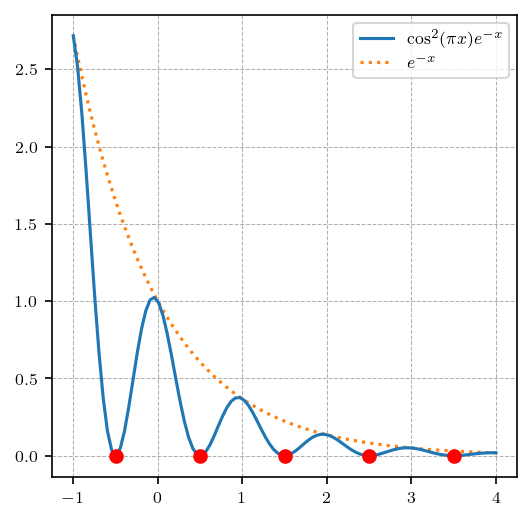

In [11]:
def f( x ):
    return ( np.cos( np. pi * x ) ** 2 ) * np.exp( -x )

x = np.linspace( -1, 4, 100 )
pp.figure( figsize = ( 4, 4 ) )
pp.plot( x, f( x ), zorder = 5 )
pp.plot( x, np.exp( -x ), linestyle = ':' )
pp.legend( [ '$\cos^2( \pi x )e^{-x}$', '$e^{-x}$' ] )
pp.grid( linestyle = '--', linewidth = 0.5 )
pp.scatter(
    [ -0.5, 0.5, 1.5, 2.5, 3.5 ],
    [ 0.0, 0.0, 0.0, 0.0, 0.0 ],
    c = 'r', zorder = 10
)
pp.show()

Problemas de otimização podem

- Não ter nenhum otimizador (local ou global)

- Ter múltiplos otimizadores (locais ou globais)

- Ter otimizador local e não ter global

- Ser infactíveis (veremos mais pra frente)

Os métodos numérico-computacionais precisam saber lidar com isso.

<h2>5. Operações que Preservam a Solução</h2>

Somar uma constante à função objetivo não altera o otimizador, pois
$$
    f( \boldsymbol x^* ) \le f( \boldsymbol x ),
$$
se e somente se
$$
    f( \boldsymbol x^* ) + c \le f( \boldsymbol x ) + c.
$$

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_19533/1518366441.py:10: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/1518366441.py:10: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/1518366441.py:10: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\

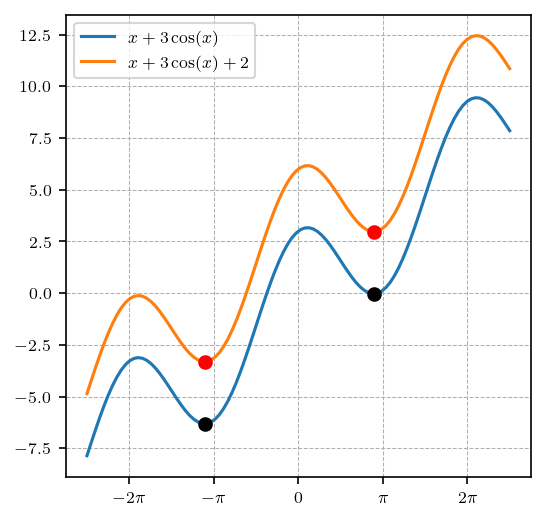

In [12]:
def f( x ):
    return x + 3 * np.cos( x )

x = np.linspace( -2.5 * np.pi, 2.5 * np.pi, 100 )
pp.figure( figsize = ( 4, 4 ) )
pp.plot( x, f( x ) )
pp.plot( x, f( x ) + 3 )
pp.xticks(
    [ -2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi ],
    [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
)
pp.legend( [ '$x + 3\cos( x )$', '$x + 3\cos( x ) + 2$' ] )
x_opt = np.pi - np.arcsin( 1 / 3 )
pp.scatter( x_opt, f( x_opt ), c = 'k', zorder = 10 )
pp.scatter( x_opt, f( x_opt ) + 3, c = 'r', zorder = 10 )
x_opt -=  2 * np.pi
pp.scatter( x_opt, f( x_opt ), c = 'k', zorder = 10 )
pp.scatter( x_opt, f( x_opt ) + 3, c = 'r', zorder = 10 )
pp.grid( linestyle = '--', linewidth = 0.5 )
pp.show()

Multiplicar a função objetivo por uma constante **positiva** não altera o otimizador, pois
$$
    f( \boldsymbol x^* ) \le f( \boldsymbol x ),
$$
se e somente se
$$
    cf( \boldsymbol x^* ) \le cf( \boldsymbol x ).
$$

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_19533/2824735924.py:10: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/2824735924.py:10: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/2824735924.py:10: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/2824735924.py:10: SyntaxWarning: invalid escape sequence '\p'
  

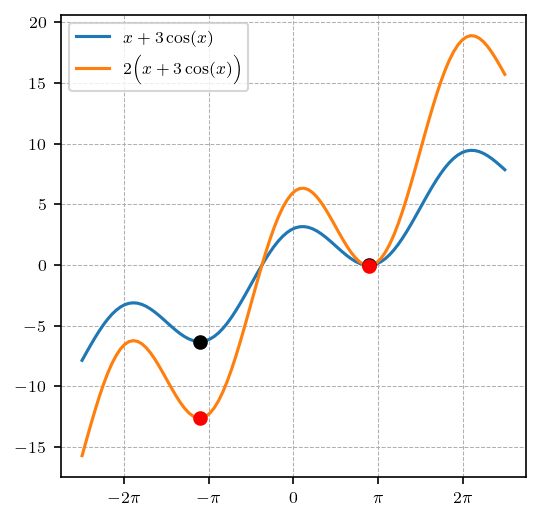

In [13]:
def f( x ):
    return x + 3 * np.cos( x )

x = np.linspace( -2.5 * np.pi, 2.5 * np.pi, 100 )
pp.figure( figsize = ( 4, 4 ) )
pp.plot( x, f( x ) )
pp.plot( x, 2 * f( x ) )
pp.xticks(
    [ -2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi ],
    [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
)
pp.legend( [ '$x + 3\cos( x )$', r'$2\bigl( x + 3\cos( x ) \bigr)$' ] )
x_opt = np.pi - np.arcsin( 1 / 3 )
pp.scatter( x_opt, f( x_opt ), c = 'k', zorder = 10 )
pp.scatter( x_opt, 2 * f( x_opt ), c = 'r', zorder = 10 )
x_opt -=  2 * np.pi
pp.scatter( x_opt, f( x_opt ), c = 'k', zorder = 10 )
pp.scatter( x_opt, 2 * f( x_opt ), c = 'r', zorder = 10 )
pp.grid( linestyle = '--', linewidth = 0.5 )
pp.show()

Em geral, se $g:\mathbb R \to \mathbb R$ é **estritamente crescente**, então $g( f( x ) )$ possui os mesmos minimizadores de $f( x )$.

O caso $g = \log$ é muito útil!

<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_19533/1671522875.py:10: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/1671522875.py:10: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/1671522875.py:10: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/1671522875.py:10: SyntaxWarning: invalid escape sequence '\p'
  

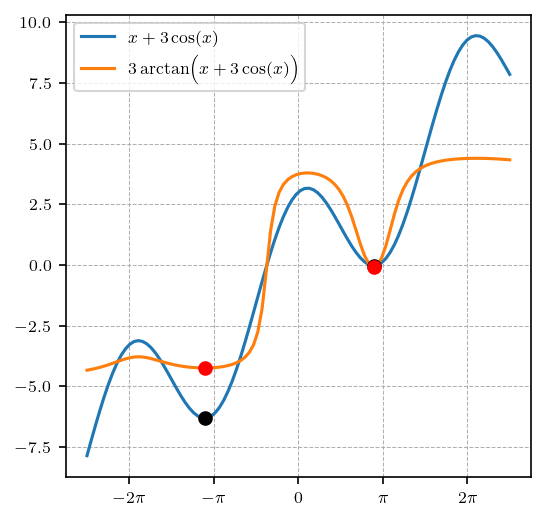

In [14]:
def f( x ):
    return x + 3 * np.cos( x )

x = np.linspace( -2.5 * np.pi, 2.5 * np.pi, 100 )
pp.figure( figsize = ( 4, 4 ) )
pp.plot( x, f( x ) )
pp.plot( x, 3 * np.arctan( f( x ) ) )
pp.xticks(
    [ -2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi ],
    [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
)
pp.legend( [ '$x + 3\cos( x )$', r'$3\arctan\bigl( x + 3\cos( x ) \bigr)$' ] )
x_opt = np.pi - np.arcsin( 1 / 3 )
pp.scatter( x_opt, f( x_opt ), c = 'k', zorder = 10 )
pp.scatter( x_opt, 3 * np.arctan( f( x_opt ) ), c = 'r', zorder = 10 )
x_opt -=  2 * np.pi
pp.scatter( x_opt, f( x_opt ), c = 'k', zorder = 10 )
pp.scatter( x_opt, 3 * np.arctan( f( x_opt ) ), c = 'r', zorder = 10 )
pp.grid( linestyle = '--', linewidth = 0.5 )
pp.show()

<h2>Otimização Univariada sem Restrições</h2>

A dificuldade do problema de otimização depende em grande medida do número de variáveis de decisão. Sob este ponto de vista, os problemas mais fáceis são os univariados, ou seja, aqueles onde temos
$$
    f : \mathbb R \to \mathbb R.
$$

Para resolver numericamente problemas univariados e sem restrições, isto é, problemas da forma
$$
    \begin{align*}
        \min &\quad f(x)\\
        \sa  &\quad x \in \mathbb R,
    \end{align*}
$$
temos a rotina ```scipy.optimize.minimize_scalar```. Veja abaixo exemplos de uso dessa rotina.

In [15]:
import scipy.optimize as opt

def f( x ):
    return ( np.cos( np. pi * x ) ** 2 ) * np.exp( -x )

res = opt.minimize_scalar( f )
print( res )

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: 9.222732403638194e-21
       x: 2.499999999893304
     nit: 9
    nfev: 13


In [16]:
print( res.message )
print( f'x = {res.x}' )
print( f'f( x ) = {res.fun}' )


Optimization terminated successfully;
The returned value satisfies the termination criteria
(using xtol = 1.48e-08 )
x = 2.499999999893304
f( x ) = 9.222732403638194e-21


In [17]:
def f( x ):
    return x + 3 * np.cos( x )

res = opt.minimize_scalar( f )
print( res )

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: -0.026671380610518547
       x: 2.801755743594779
     nit: 10
    nfev: 14


In [18]:
print( res.x )
print( np.pi - np.arcsin( 1 / 3 ) )

2.801755743594779
2.8017557441356713


Isto mostra que a rotina ```scipy.optimize.minimize_scalar``` contenta-se com otimizadores locais.

Será que a otimização sempre funciona?

In [19]:
def f( x ):
    return np.exp( -x )

res = opt.minimize_scalar( f )
print( res )

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: 0.0
       x: 1362.3827864296177
     nit: 35
    nfev: 59


Veja que nesse caso, a solução retornada não é um otimizador no sentido estrito, mas poderia ter sido útil na prática.

Em alguns casos a rotina falha e detecta a falha, como abaixo.

In [20]:
def f( x ):
    return -x

res = opt.minimize_scalar( f )
print( res )

 message: The algorithm terminated without finding a valid bracket. Consider trying different initial points.
 success: False
     fun: -inf
       x: inf
     nit: 0
    nfev: 803


/home/junior/Documentos/GitHub/curso-cdpo-usp/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:3057: RuntimeWarning: overflow encountered in scalar multiply
  if (w - xc) * (xb - w) > 0.0:
/home/junior/Documentos/GitHub/curso-cdpo-usp/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:3073: RuntimeWarning: overflow encountered in scalar multiply
  elif (w - wlim)*(wlim - xc) >= 0.0:
/home/junior/Documentos/GitHub/curso-cdpo-usp/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:3049: RuntimeWarning: overflow encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/junior/Documentos/GitHub/curso-cdpo-usp/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:3049: RuntimeWarning: overflow encountered in scalar multiply
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/junior/Documentos/GitHub/curso-cdpo-usp/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:3042: RuntimeWarning: ove

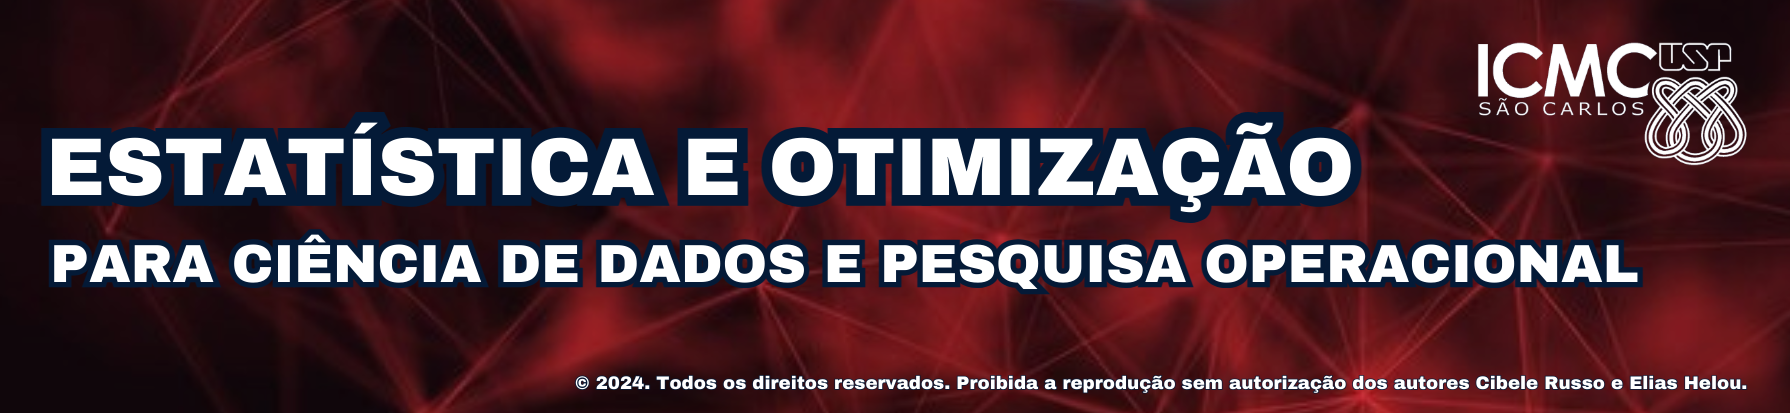

<h1 style = 'text-align: center;'>Usando a Função <code>scipy.optimize.minimize_scalar</code></h1>

por **Elias Helou**

**ICMC/USP - São Carlos SP**

<h2>Conteúdo do vídeo</h2>

1. Consultando a documentação

2. Direcionando a busca

3. Especificando intervalo de busca

<h2>1. Consultando a Documentação</h2>

A função nativa do Python ```help()``` deve sempre ser utilizada. A documentação na web pode ser mais legível, mas o uso de ```help()``` pode ser bastante conveniente.

In [21]:
import scipy.optimize as opt

help( opt.minimize_scalar )

Help on function minimize_scalar in module scipy.optimize._minimize:

minimize_scalar(
    fun,
    bracket=None,
    bounds=None,
    args=(),
    method=None,
    tol=None,
    options=None
)
    Local minimization of scalar function of one variable.

    Parameters
    ----------
    fun : callable
        Objective function.
        Scalar function, must return a scalar.

        Suppose the callable has signature ``f0(x, *my_args, **my_kwargs)``, where
        ``my_args`` and ``my_kwargs`` are required positional and keyword arguments.
        Rather than passing ``f0`` as the callable, wrap it to accept
        only ``x``; e.g., pass ``fun=lambda x: f0(x, *my_args, **my_kwargs)`` as the
        callable, where ``my_args`` (tuple) and ``my_kwargs`` (dict) have been
        gathered before invoking this function.

    bracket : sequence, optional
        For methods 'brent' and 'golden', `bracket` defines the bracketing
        interval and is required.
        Either a triple ``(x

Há informações importantes na documentação:

- O algoritmo usado é o método de Brent ou o da seção dourada

    - Ambos vão reduzindo o intervalo que contém o otimizador

    - Ambos requerem uma função **unimodal** no intervalo

- É possível estipular um par de pontos iniciais

    - A função procura encontrar um intervalo inicial a partir de dois pontos usando a rotina ```scipy.optimize.bracket```

- É possível restringir a busca a um intervalo dado

<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_19533/3889896634.py:15: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/3889896634.py:15: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/3889896634.py:15: SyntaxWarning: invalid escape sequence '\p'
  [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
/tmp/ipykernel_19533/3889896634.py:15: SyntaxWarning: invalid escape sequence '\p'
  

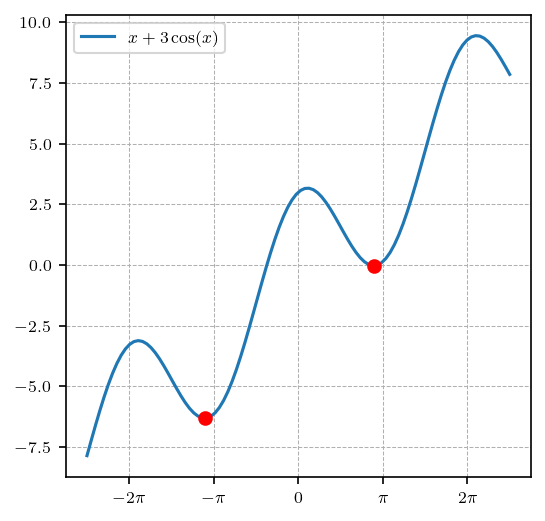

In [22]:
import matplotlib.pyplot as pp
pp.rcParams[ 'text.usetex' ] = True
pp.rcParams[ 'font.size' ] = 8
pp.rcParams[ 'figure.dpi' ] = 150
import numpy as np

def f( x ):
    return x + 3 * np.cos( x )

x = np.linspace( -2.5 * np.pi, 2.5 * np.pi, 100 )
pp.figure( figsize = ( 4, 4 ) )
pp.plot( x, f( x ) )
pp.xticks(
    [ -2 * np.pi, -np.pi, 0, np.pi, 2 * np.pi ],
    [ '$-2\pi$', '$-\pi$', '$0$', '$\pi$', '$2\pi$' ]
)
pp.legend( [ '$x + 3\cos( x )$' ] )
x_opt = np.pi - np.arcsin( 1 / 3 )
pp.scatter( x_opt, f( x_opt ), c = 'r', zorder = 10 )
x_opt -=  2 * np.pi
pp.scatter( x_opt, f( x_opt ), c = 'r', zorder = 10 )
pp.grid( linestyle = '--', linewidth = 0.5 )
pp.show()

In [23]:
def f( x ):
    return x + 3 * np.cos( x )

res = opt.minimize_scalar( f )
print( res )

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: -0.026671380610518547
       x: 2.801755743594779
     nit: 10
    nfev: 14


<h2>2. Direcionando a Busca</h2>

Para direcionar a busca, utilizamos o argumento ```bracket``` da função.


Este argumento determina a direção em que o método irá buscar um intervalo em que a função suba depois de descer e seu valor padrão é ```( 0, 1 )```.

In [24]:
res = opt.minimize_scalar( f, bracket = ( 0, 3, 4 ) )
print( res )

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: -0.026671380610518547
       x: 2.8017557429702915
     nit: 9
    nfev: 12


In [25]:
res = opt.minimize_scalar( f, bracket = ( 0, -1 ) )
print( res )

 message: 
          Optimization terminated successfully;
          The returned value satisfies the termination criteria
          (using xtol = 1.48e-08 )
 success: True
     fun: -6.309856687790106
       x: -3.481429563378135
     nit: 10
    nfev: 14


In [26]:
res = opt.minimize_scalar( f, bracket = ( 1, 5 ) )
print( res )

/home/junior/Documentos/GitHub/curso-cdpo-usp/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:3057: RuntimeWarning: overflow encountered in scalar multiply
  if (w - xc) * (xb - w) > 0.0:
/home/junior/Documentos/GitHub/curso-cdpo-usp/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:3077: RuntimeWarning: overflow encountered in scalar multiply
  elif (w - wlim)*(xc - w) > 0.0:
/home/junior/Documentos/GitHub/curso-cdpo-usp/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:3073: RuntimeWarning: overflow encountered in scalar multiply
  elif (w - wlim)*(wlim - xc) >= 0.0:
/home/junior/Documentos/GitHub/curso-cdpo-usp/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:3049: RuntimeWarning: overflow encountered in scalar divide
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom
/home/junior/Documentos/GitHub/curso-cdpo-usp/.venv/lib/python3.13/site-packages/scipy/optimize/_optimize.py:3049: RuntimeWarning: overflow encountered in sc

RuntimeError: No valid bracket was found before the iteration limit was reached. Consider trying different initial points or increasing `maxiter`.

<h3>3. Especificando o Intervalo de Busca</h3>

Podemos resolver problemas univariados com restrições específicas usando a função ```scipy.optimize.minimize_scalar```. Se o problema a ser resolvido possui a forma
$$\def\sa{\text{s.\ a:}}
    \begin{align*}
        \min &\quad f( x )\\
        \sa  &\quad x \in [ a, b ].
    \end{align*}
$$

Para incluir a restrição $x \in [ a, b ]$ no problema, utilizamos o parâmetro ```bounds``` e especificamos o método ```'bounded'```, como no exemplo abaixo.


In [27]:
res = opt.minimize_scalar( f, bounds = ( 1.5, 4 ), method = 'bounded' )
print( res )

 message: Solution found.
 success: True
  status: 0
     fun: -0.026671380609435413
       x: 2.80175486879398
     nit: 9
    nfev: 9


<h3>Resumo da Aula</h3>

Aprendemos o que é um problema de otimização matemática, definido através da função objetivo, conjunto viável e restrições. Vimos os conceitos de otimizador local e otimizador global.

Vimos alguns exemplos de problemas simples de otimização e notamos que há operações que não alteram os otimizadores.

Alem disso, aprendemos que a função ```scipy.optimize.minimize_scalar``` é capaz de resolver problemas de otimização univariados com restrições "simples". Mais precisamente, ele funciona para problemas com a forma
$$\def\sa{\text{s.\ a:}}
    \begin{align*}
        \min &\quad f( x )\\
        \sa  &\quad x \in [ a, b ].
    \end{align*}
$$

- A função $f$ deve ser contínua e, preferencialmente, suave

- A função $f$ deve ser unimodal no intervalo inicial de busca

- Ela pode funcionar sem que as propriedades acima sejam satisfeitas, mas não há garantias

- O usuário irá obter um minimizador local

- Somente há suporte para restrições do tipo $x \in [ a, b ]$